# Combinatorial CoWork 2026 — Notebook 05: Noisy annulus and an `H^1` 2-persistence picture

Audience:
- Participants who want a point-cloud-side ingestion example that still lands on a mathematically interpretable degree-1 dimension picture.

Learning goals:
- Build a genuinely noisy annulus with interior points from the synthetic-data surface.
- Declare a `RipsCodensityFiltration` with the now-canonical DTM-style codensity contract.
- Use `point_codensity(...)` as the raw-cloud-side object that shares the same codensity semantics as the downstream filtration.
- Reproduce a notebook-friendly codensity/radius snapshot panel for the raw cloud.
- Compute `stage=:cohomology_dims` in degree `1` and render the corresponding `H^1` dimension plane.


## Outline

1. Setup and build a noisy annulus with genuine interior noise
2. Inspect the point cloud and the codensity filtration contract
3. Compute pointwise codensity values for raw-cloud plotting
4. Draw a codensity/radius snapshot panel
5. Compute degree-1 cohomology dimensions and inspect the `H^1` dimension plane
6. Export the main figures


In [13]:
NOTEBOOK_STEM = "05_noisy_annulus_rips_codensity_h1_2persistence"

_TO_ROOT = let
    dir = abspath(pwd())
    root = nothing
    while true
        if isfile(joinpath(dir, "Project.toml")) && isfile(joinpath(dir, "src", "TamerOp.jl"))
            root = dir
            break
        end
        parent = dirname(dir)
        parent == dir && error("Could not locate repo root containing Project.toml and src/TamerOp.jl from pwd()=$(pwd()).")
        dir = parent
    end
    root
end

import Pkg
Pkg.activate(_TO_ROOT; io=devnull)

if !isdefined(Main, :TamerOp)
    @eval Main using TamerOp
end

TO = Main.TamerOp
using CairoMakie
CairoMakie.activate!(type="png")

using Random
using Statistics

CM = TO.CoreModules
OPT = TO.Options
SD = TO.SyntheticData
outdir = joinpath(_TO_ROOT, "examples", "_outputs", "combinatorial_cowork_2026", NOTEBOOK_STEM)
mkpath(outdir)


"/home/eriknovak/Documents/duke_fall_2025/tamer-op/examples/_outputs/combinatorial_cowork_2026/05_noisy_annulus_rips_codensity_h1_2persistence"

## 1. Build a noisy annulus with actual interior noise

`noisy_annulus(...)` is the synthetic-data source object we want here. We choose enough diffuse noise points that the middle of the annulus is visibly contaminated, so the codensity axis has something real to separate.


In [14]:
rng = MersenneTwister(20260323)
cloud = SD.noisy_annulus(
    n_annulus=120,
    n_noise=30,
    r_inner=0.75,
    r_outer=1.05,
    rng=rng,
)

cloud


PointCloud
  npoints: 150
  ambient_dim: 2
  eltype: Float64

The first inspection step is still the generic UX surface. `describe(...)` tells us what object we built, and `available_visuals(...)` shows that the point cloud is immediately ready for notebook-side visualization.


In [15]:
cloud_description = TO.describe(cloud)
cloud_visuals = TO.available_visuals(cloud)

(; cloud_description, cloud_visuals)


(cloud_description = (kind = :point_cloud, npoints = 150, ambient_dim = 2, eltype = Float64), cloud_visuals = (:points_2d, :point_density, :knn_graph, :radius_graph))

## 2. Declare the Rips-codensity filtration

This notebook uses the public codensity filtration, not an ad hoc notebook-side surrogate. The first parameter is the ordinary Rips radius, and the second is the DTM-style codensity statistic controlled by `dtm_mass`. That is the same codensity contract now used by the parity-clean Euler benchmark lane against `multipers`.


In [23]:
construction = TO.ConstructionOptions(
    ;
    sparsify=:knn,
    collapse=:none,
    budget=(max_simplices=120_000, max_edges=80_000, memory_budget_bytes=1_000_000_000),
)

filtration = TO.RipsCodensityFiltration(
    ;
    max_dim=1,
    knn=10,
    dtm_mass=0.24,
    nn_backend=:auto,
    construction=construction,
)

filtration_description = TO.describe(filtration)
filtration_params = TO.filtration_parameters(filtration)

(; filtration_description, filtration_params)


(filtration_description = (kind = :rips_codensity, filtration_type = :RipsCodensityFiltration, arity = 2, key_params = (max_dim = 1, knn = 10, nn_backend = :auto, nn_approx_candidates = 0, dtm_mass = 0.24), construction_mode = (sparsify = :knn, collapse = :none, output_stage = :encoding_result)), filtration_params = (max_dim = 1, knn = 10, nn_backend = :auto, nn_approx_candidates = 0, dtm_mass = 0.24, construction = (sparsify = :knn, collapse = :none, output_stage = :encoding_result, budget = (max_simplices = 120000, max_edges = 80000, memory_budget_bytes = 1000000000))))

## 3. Compute reusable point codensity values

The codensity values themselves are now a reusable library object rather than notebook-local scaffolding. `point_codensity(...)` gives us the pointwise DTM-style codensity values attached to this cloud and this `RipsCodensityFiltration`, so the raw-cloud plots and the downstream encoded filtration are reading the same statistic.


In [24]:
pcod = TO.point_codensity(cloud, filtration)
snapshot_radii = [0.07, 0.16, 0.30]

pcod_description = TO.describe(pcod)

(; pcod_description,
   dtm_mass=TO.codensity_mass(pcod),
   neighbor_count=TO.neighbor_count(pcod),
   available_visuals=TO.available_visuals(pcod))


(pcod_description = (kind = :point_codensity_result, data_kind = :point_cloud, npoints = 150, ambient_dim = 2, filtration_kind = :rips_codensity, dtm_mass = 0.24, neighbor_count = 37, value_range = (0.30247053233732635, 0.704843948659375)), dtm_mass = 0.24, neighbor_count = 37, available_visuals = (:points_2d, :point_density, :knn_graph, :radius_graph, :codensity_radius_snapshots))

The point cloud can now be plotted directly from the codensity result object. The visual kind stays the ordinary point-cloud one, but the colors come from the codensity values automatically.


In [25]:
cloud_spec = TO.Visualization.visual_spec(pcod; kind=:points_2d)

(; cloud_visual_summary=TO.Visualization.visual_summary(cloud_spec))


(cloud_visual_summary = (kind = :visualization_spec, visual_kind = :points_2d, title = "Point cloud preview", subtitle = "2D point-cloud view", nlayers = 1, npanels = 0, layer_types = (:PointLayer,), axes = (xlabel = "x1", ylabel = "x2", xlimits = (-1.1714403329825254, 1.1440068438258708), ylimits = (-1.235727952076565, 1.2817442390962293), zlabel = "z", zlimits = nothing, aspect = :equal, xticks = nothing, yticks = nothing), metadata = (object = :point_codensity_result, projected_dims = (1, 2), ambient_dim = 2, npoints = 150, overlay_density = false, legend_position = :none, figure_size = (720, 520), dtm_mass = 0.24, neighbor_count = 37, value_range = (0.30247053233732635, 0.704843948659375)), legend_visible = false, interaction = (hover = true, labels = false, clicks = false, widgets = (), notebook = :summary_card)),)

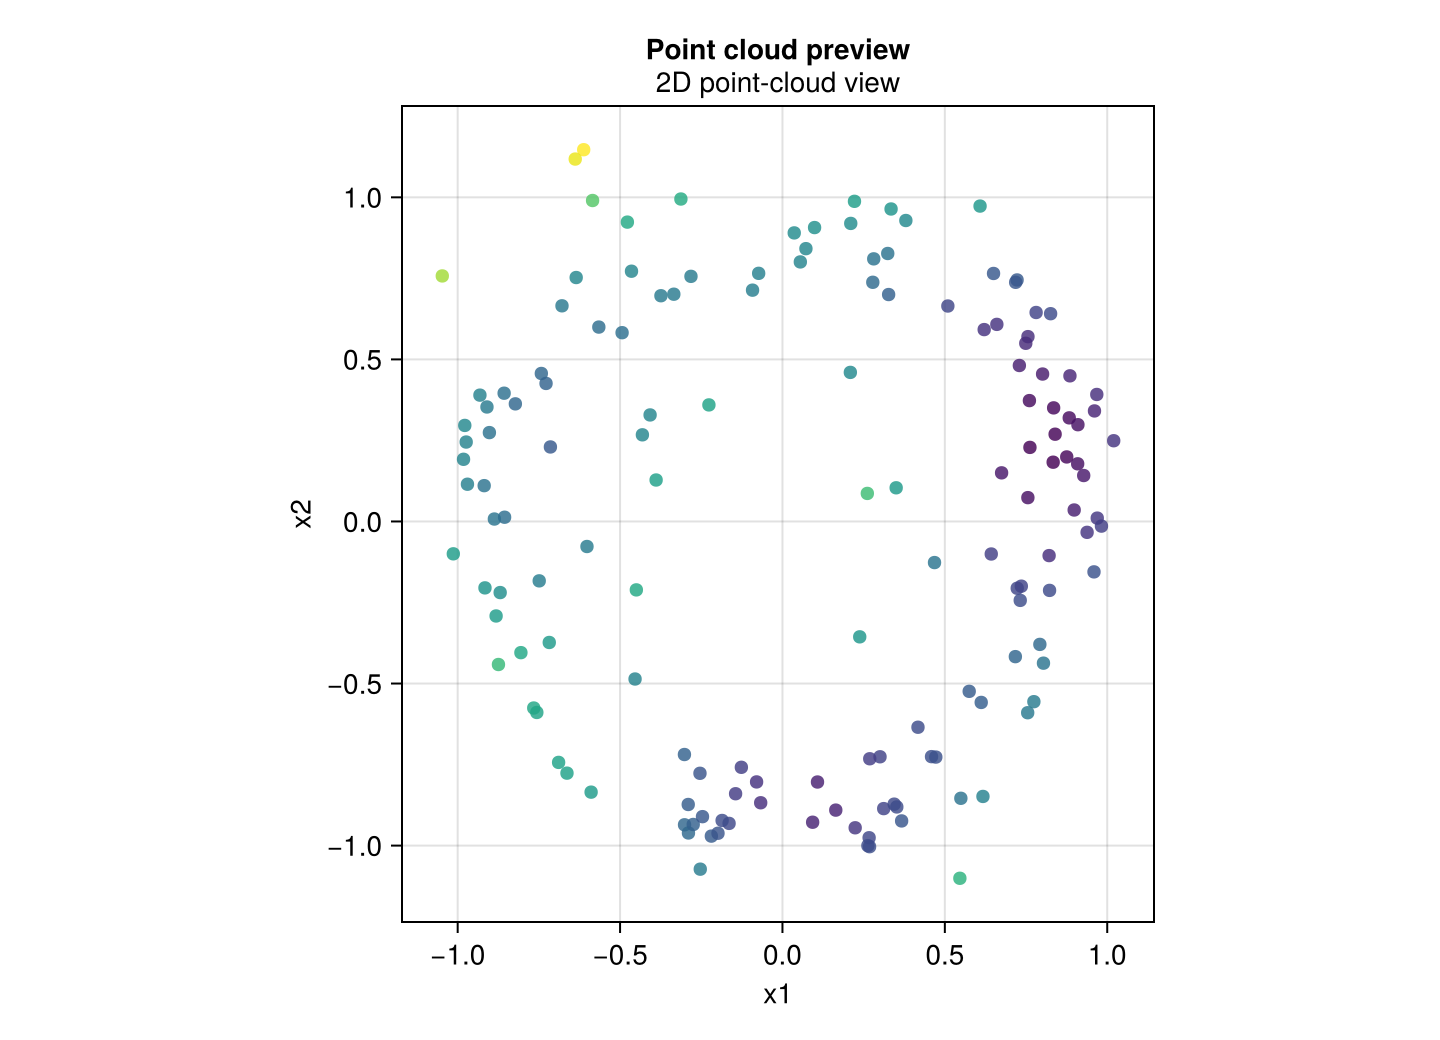

In [26]:
TO.visualize(pcod; kind=:points_2d, backend=:cairomakie)


## 4. Draw the codensity/radius snapshot panel

The snapshot montage is now a first-class visualization on `PointCodensityResult`, so the raw-cloud view and the downstream persistence view stay tied to one codensity object. The interpretation is:
- rows filter by codensity cutoff,
- columns increase the radius,
- point colors still record the codensity values.


In [27]:
snapshot_spec = TO.Visualization.visual_spec(
    pcod;
    kind=:codensity_radius_snapshots,
    radii=snapshot_radii,
    codensity_levels=:quantiles,
)

(; snapshot_visual_summary=TO.Visualization.visual_summary(snapshot_spec))


(snapshot_visual_summary = (kind = :visualization_spec, visual_kind = :codensity_radius_snapshots, title = "Codensity/radius snapshots", subtitle = "rows filter by codensity cutoff; columns increase radius", nlayers = 0, npanels = 9, layer_types = (), axes = (xlabel = "x", ylabel = "y", xlimits = nothing, ylimits = nothing, zlabel = "z", zlimits = nothing, aspect = :auto, xticks = nothing, yticks = nothing), metadata = (object = :point_codensity_result, dtm_mass = 0.24, neighbor_count = 37, nlevels = 3, nradii = 3, codensity_levels = (0.40545615613728975, 0.46465203854392034, 0.5140773655374262), radii = (0.07, 0.16, 0.3), panel_columns = 3, figure_size = (980, 760)), legend_visible = false, interaction = (hover = false, labels = false, clicks = false, widgets = (), notebook = :summary_card)),)

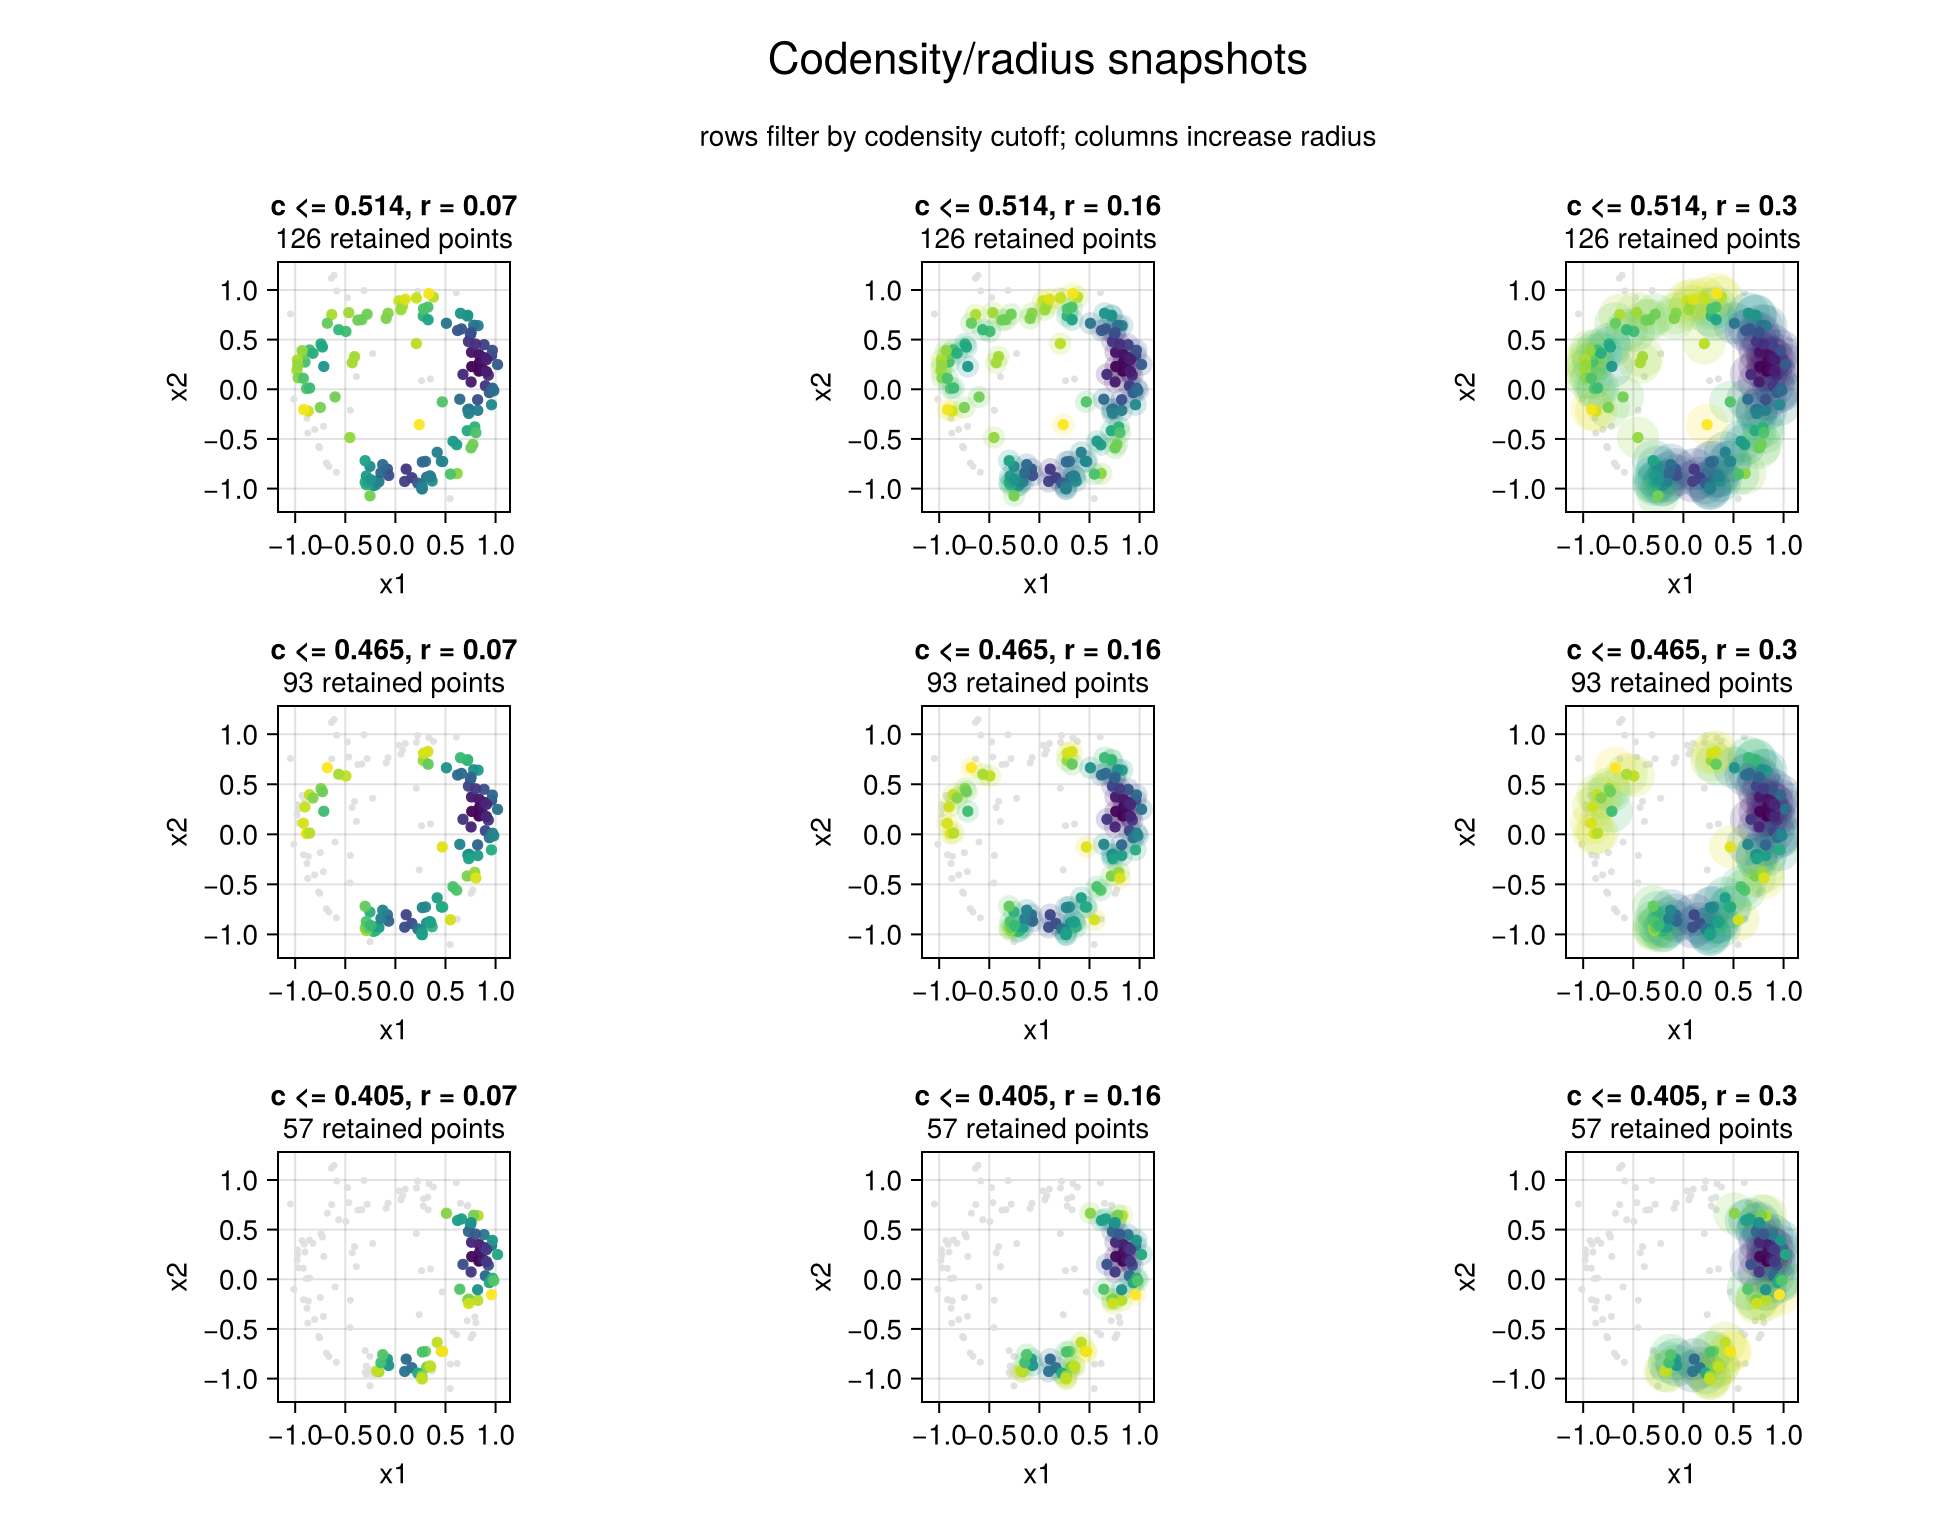

In [28]:
TO.visualize(pcod; kind=:codensity_radius_snapshots, radii=snapshot_radii, codensity_levels=:quantiles, backend=:cairomakie)


## 5. Compute degree-1 cohomology dimensions and inspect the `H^1` dimension plane

Now we keep the encoding-first story explicit: point cloud + typed filtration in, cheap cohomology-dims object out. `stage=:cohomology_dims` gives a degree-1 summary object, and `kind=:cohomology_support_plane` turns that into the notebook-facing 2-parameter dimension picture.

We use `F2()` here because this is a dims-only point-cloud demo; for this annulus, the degree-1 support story is the same, and `F2()` keeps the runtime modest.


In [29]:
h1_dims = TO.encode(
    cloud,
    filtration;
    degree=1,
    stage=:cohomology_dims,
    field=CM.F2(),
    cache=:auto,
)

h1_description = TO.describe(h1_dims)
h1_spec = TO.Visualization.visual_spec(h1_dims; kind=:cohomology_support_plane)

(; h1_description, h1_visual_summary=TO.Visualization.visual_summary(h1_spec), available_visuals=TO.available_visuals(h1_dims))


(h1_description = (kind = :cohomology_dims_result, poset_type = TamerOp.FiniteFringe.ProductOfChainsPoset{2}, dims_type = Vector{Int64}, dims_length = 133650, encoding_map_type = TamerOp.EncodingCore.CompiledEncoding{TamerOp.EncodingCore.GridEncodingMap{2, Float64, TamerOp.FiniteFringe.ProductOfChainsPoset{2}}, TamerOp.FiniteFringe.ProductOfChainsPoset{2}, Tuple{Vector{Float64}, Vector{Float64}}, Vector{Tuple{Float64, Float64}}, @NamedTuple{encoding_cache::TamerOp.CoreModules.EncodingCache}}, compiled = true, degree = 1, field_type = TamerOp.CoreModules.CoeffFields.PrimeField), h1_visual_summary = (kind = :visualization_spec, visual_kind = :cohomology_support_plane, title = "H^1 dimension plane", subtitle = "cohomology dimensions on the bifiltration parameter plane", nlayers = 2, npanels = 0, layer_types = (:RectLayer, :HeatmapLayer), axes = (xlabel = "x1", ylabel = "x2", xlimits = (-0.0030407293767422965, 0.5574880593037802), ylimits = (0.301436268637917, 0.7109806624534794), zlabel =

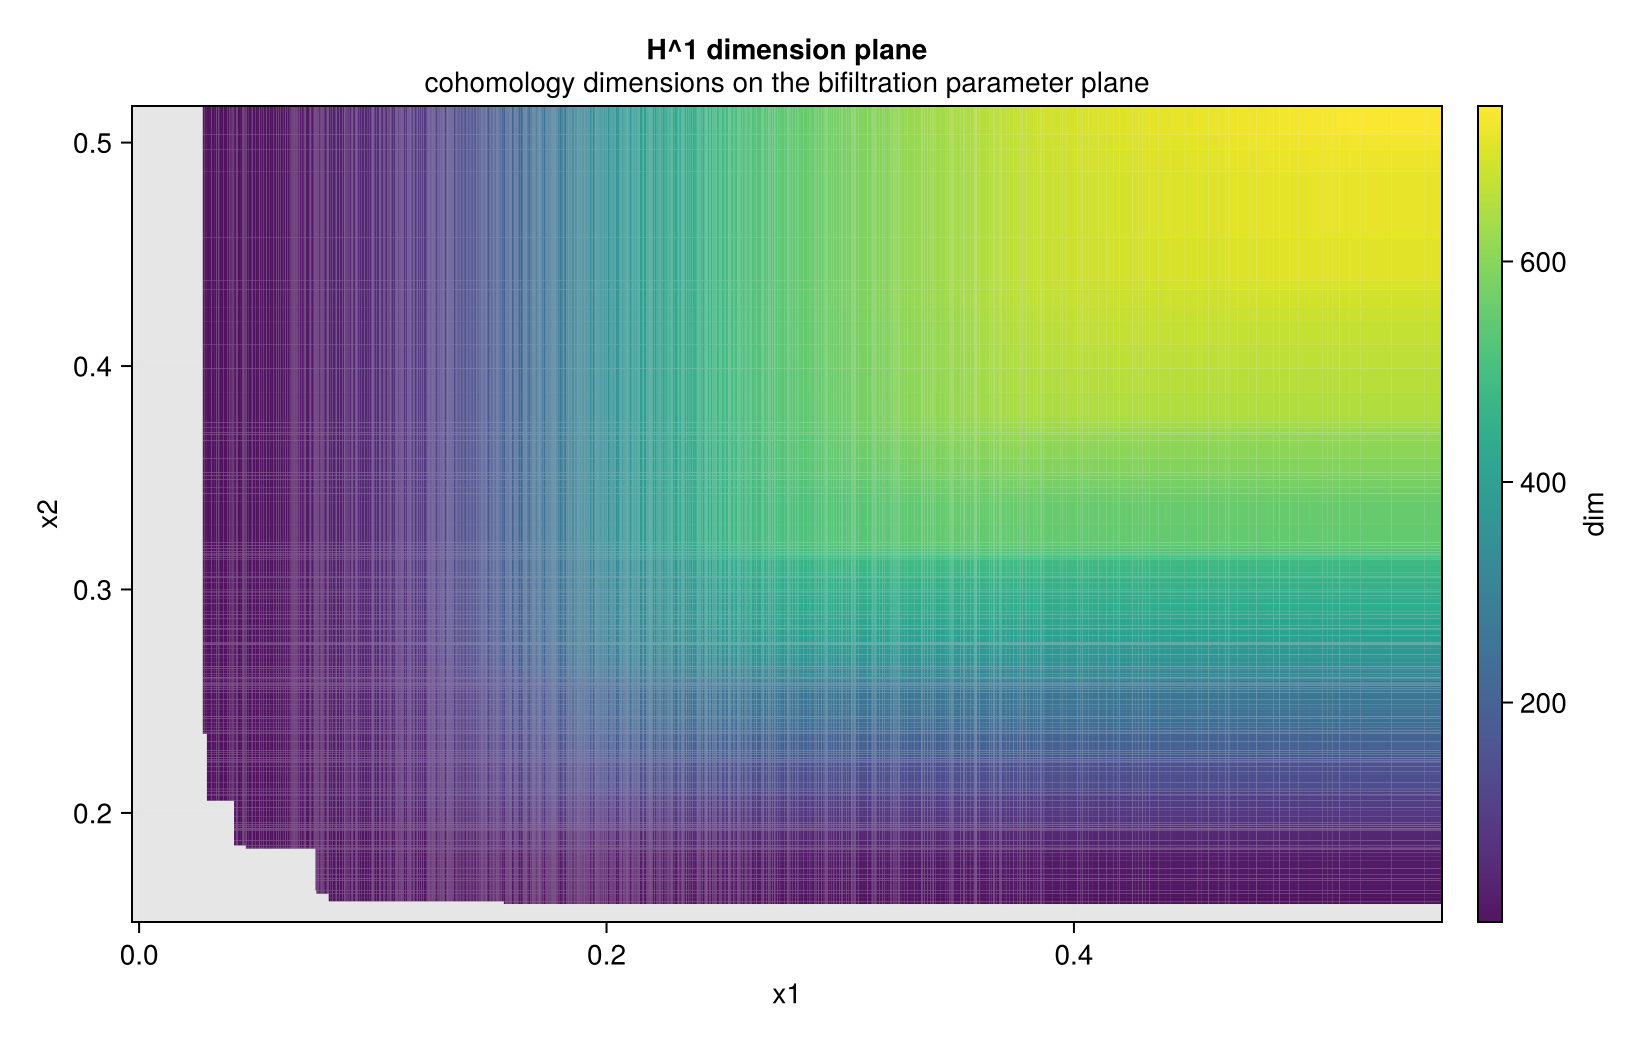

In [11]:
TO.visualize(h1_dims; kind=:cohomology_support_plane, backend=:cairomakie)


## 6. Export the main figures

All three visuals now live on the public library surface, so we export them uniformly through `save_visuals(...)`.


In [12]:
exports = TO.save_visuals(outdir, [
    (; stem="annulus_codensity_points", obj=pcod, kind=:points_2d),
    (; stem="annulus_codensity_radius_snapshots", obj=pcod, kind=:codensity_radius_snapshots,
       radii=snapshot_radii, codensity_levels=:quantiles),
    (; stem="annulus_h1_support_plane", obj=h1_dims, kind=:cohomology_support_plane),
]; format=:png, backend=:cairomakie)

Dict(TO.export_stem(r) => TO.export_path(r) for r in exports)


Dict{String, String} with 3 entries:
  "annulus_codensity_points"           => "/home/eriknovak/Documents/duke_fall_…
  "annulus_codensity_radius_snapshots" => "/home/eriknovak/Documents/duke_fall_…
  "annulus_h1_support_plane"           => "/home/eriknovak/Documents/duke_fall_…

## Try this next

- Increase `n_noise` and rerun only sections 1, 4, and 5. The codensity snapshot panel should fill in toward the center, and the `H^1` dimension plane should shrink.
- Increase `dtm_mass` and rerun sections 2, 3, 4, and 5. This makes the codensity statistic more global, so the snapshot rows become less permissive.
- Change the field in section 5 from `F2()` to `QQField()` if you want to verify that the degree-1 dimension picture is unchanged for this annulus.
- Swap section 5 to an Euler computation on the same filtration if you want to inspect the codensity invariant lane that is now benchmarked cleanly against `multipers`.
